# 🏠 House Price Prediction — Modélisation
## Objectif
Entraîner et comparer plusieurs modèles ML pour prédire le prix des maisons.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Charger les données preprocessées
X = pd.read_csv('../data/processed/X_scaled.csv')
y = pd.read_csv('../data/processed/y.csv').squeeze()

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (1166, 259)
Test : (292, 259)


In [2]:
# Entraînement des modèles
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10),
    'Lasso': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Entraînement
    model.fit(X_train, y_train)
    
    # Prédiction
    y_pred = model.predict(X_test)
    
    # Métriques
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'RMSE': round(rmse, 4), 'R²': round(r2, 4)}
    print(f"{name} → RMSE: {rmse:.4f} | R²: {r2:.4f}")

Linear Regression → RMSE: 0.1373 | R²: 0.8881
Ridge → RMSE: 0.1326 | R²: 0.8957
Lasso → RMSE: 0.1287 | R²: 0.9018
Random Forest → RMSE: 0.1468 | R²: 0.8722


C:\Users\amine\AppData\Local\Temp\ipykernel_380\2429734776.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['RMSE'], palette='coolwarm', ax=ax1)
C:\Users\amine\AppData\Local\Temp\ipykernel_380\2429734776.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['R²'], palette='coolwarm', ax=ax2)


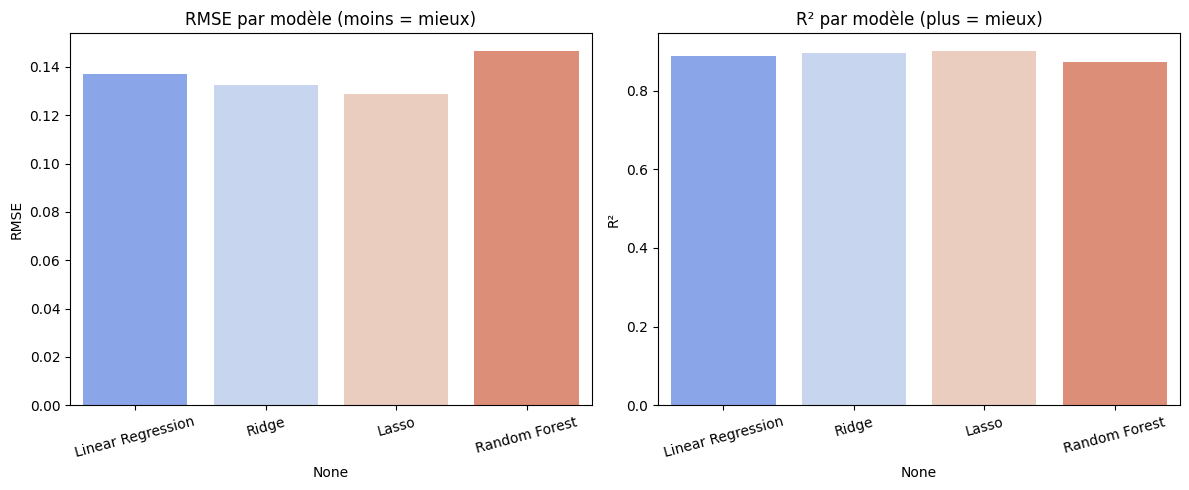

In [3]:
# Visualisation des résultats
results_df = pd.DataFrame(results).T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# RMSE
sns.barplot(x=results_df.index, y=results_df['RMSE'], palette='coolwarm', ax=ax1)
ax1.set_title('RMSE par modèle (moins = mieux)')
ax1.set_ylabel('RMSE')
ax1.tick_params(axis='x', rotation=15)

# R²
sns.barplot(x=results_df.index, y=results_df['R²'], palette='coolwarm', ax=ax2)
ax2.set_title('R² par modèle (plus = mieux)')
ax2.set_ylabel('R²')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Réentraînement sur 100% des données d'entraînement
Le meilleur modèle (Lasso) est réentraîné sur la totalité du train pour maximiser l'information apprise.

In [4]:
# Le meilleur modèle selon les résultats : Lasso
best_model = Lasso(alpha=0.001)

# Évaluation honnête par cross-validation sur X complet
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="neg_mean_squared_error")
cv_rmse = np.sqrt(-cv_scores)
print(f"CV RMSE (5-fold) : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

# Réentraînement final sur 100% du train
best_model.fit(X, y)
print("Modèle réentraîné sur 100% du train — prêt pour prédiction test")

CV RMSE (5-fold) : 0.1177 ± 0.0060
Modèle réentraîné sur 100% du train — prêt pour prédiction test


## Prédiction sur test.csv
On applique le même preprocessing que sur train, puis on prédit avec le modèle final.

In [ ]:
from sklearn.preprocessing import StandardScaler

# --- Recharger train pour recréer le scaler ---
train_raw = pd.read_csv("../data/train.csv")
train_raw = train_raw[~((train_raw["GrLivArea"] > 4000) & (train_raw["SalePrice"] < 200000))]

cols_none = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "MasVnrType"]
cols_zero = ["GarageYrBlt", "GarageArea", "GarageCars",
             "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
             "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"]

for col in cols_none: train_raw[col] = train_raw[col].fillna("None")
for col in cols_zero: train_raw[col] = train_raw[col].fillna(0)
train_raw["LotFrontage"] = train_raw.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
train_raw["Electrical"] = train_raw["Electrical"].fillna(train_raw["Electrical"].mode()[0])

train_encoded = pd.get_dummies(train_raw.drop("SalePrice", axis=1), drop_first=True)
scaler = StandardScaler()
scaler.fit(train_encoded)

# --- Preprocessing test.csv ---
test_raw = pd.read_csv("../data/test.csv")
test_ids = test_raw["Id"]

for col in cols_none: test_raw[col] = test_raw[col].fillna("None")
for col in cols_zero: test_raw[col] = test_raw[col].fillna(0)
test_raw["LotFrontage"] = test_raw.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
test_raw["Electrical"] = test_raw["Electrical"].fillna(test_raw["Electrical"].mode()[0])

test_encoded = pd.get_dummies(test_raw, drop_first=True)

# Aligner les colonnes avec le train
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

test_scaled = scaler.transform(test_encoded)

# --- Prédiction ---
y_pred_log = best_model.predict(test_scaled)
y_pred_final = np.exp(y_pred_log)  # Inverser la transformation log

# --- Sauvegarde ---
import os
os.makedirs("../data/processed", exist_ok=True)
submission = pd.DataFrame({"Id": test_ids, "SalePrice": y_pred_final})
submission.to_csv("../data/processed/submission.csv", index=False)

print("Prédictions sauvegardées dans data/processed/submission.csv")
print(submission.head(10))

Prédictions sauvegardées dans data/processed/submission.csv
     Id      SalePrice
0  1461  118527.310327
1  1462  155350.535049
2  1463  181506.702683
3  1464  200349.170727
4  1465  195017.618408
5  1466  172074.777144
6  1467  181018.067755
7  1468  164509.788328
8  1469  196836.614713
9  1470  119743.268805


C:\Users\amine\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


: 